In [1]:
import camb
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pysm3
import pysm3.units as u

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

mpl.rcParams['font.family']       = 'serif'
mpl.rcParams['font.serif']        = ['DejaVu Serif', 'Times New Roman', 'serif']
mpl.rcParams['mathtext.fontset']  = 'dejavuserif'   
mpl.rcParams['text.usetex']       = False            

mpl.rcParams['font.size']         = 14
mpl.rcParams['axes.titlesize']    = 15
mpl.rcParams['axes.labelsize']    = 14
mpl.rcParams['xtick.labelsize']   = 12
mpl.rcParams['ytick.labelsize']   = 12
mpl.rcParams['legend.fontsize']   = 12
mpl.rcParams['legend.title_fontsize'] = 13


mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['savefig.dpi']       = 600         
mpl.rcParams['savefig.bbox']      = 'tight'
mpl.rcParams['savefig.format']    = 'pdf'       

mpl.rcParams['axes.spines.top']   = True
mpl.rcParams['axes.spines.right'] = True
mpl.rcParams['axes.edgecolor']    = 'black'
mpl.rcParams['axes.linewidth']    = 1.2  


N_colores = 8                                      
cmap      = mpl.colormaps['rainbow']               
colores   = [cmap(i / (N_colores - 1)) for i in range(N_colores)]
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colores)

# --- Grilla ---
mpl.rcParams['axes.grid']         = True
mpl.rcParams['grid.color']        = '0.85'
mpl.rcParams['grid.linestyle']    = '--'
mpl.rcParams['grid.linewidth']    = 0.6
mpl.rcParams['grid.alpha']        = 0.7

# --- Ticks ---
mpl.rcParams['xtick.direction']   = 'in'
mpl.rcParams['ytick.direction']   = 'in'
mpl.rcParams['xtick.major.size']  = 5
mpl.rcParams['ytick.major.size']  = 5
mpl.rcParams['xtick.minor.size']  = 3
mpl.rcParams['ytick.minor.size']  = 3
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

# --- Lineas y markers ---
mpl.rcParams['lines.linewidth']   = 2.0
mpl.rcParams['lines.markersize']  = 6

# --- Leyenda ---
mpl.rcParams['legend.frameon']    = True
mpl.rcParams['legend.framealpha'] = 0.85
mpl.rcParams['legend.edgecolor']  = '0.8'
mpl.rcParams['legend.fancybox']   = False

mpl.rcParams['image.cmap']        = 'rainbow'    

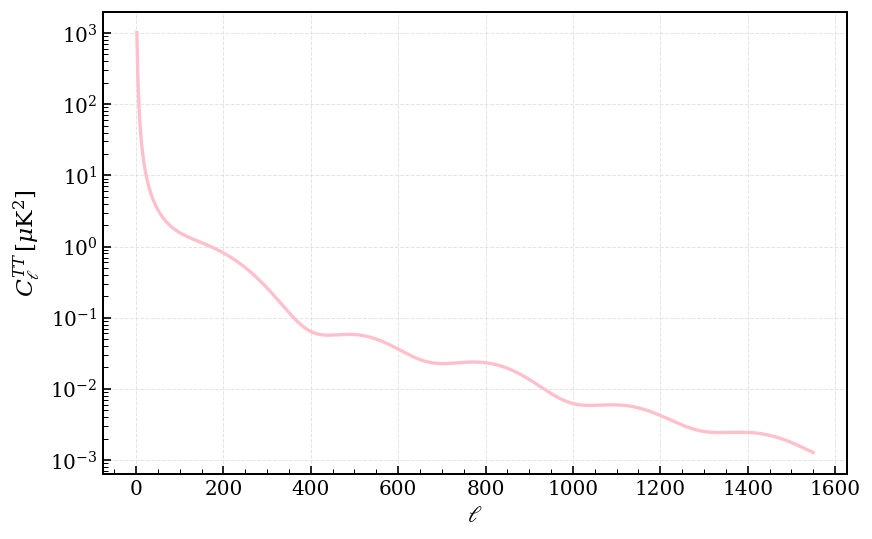

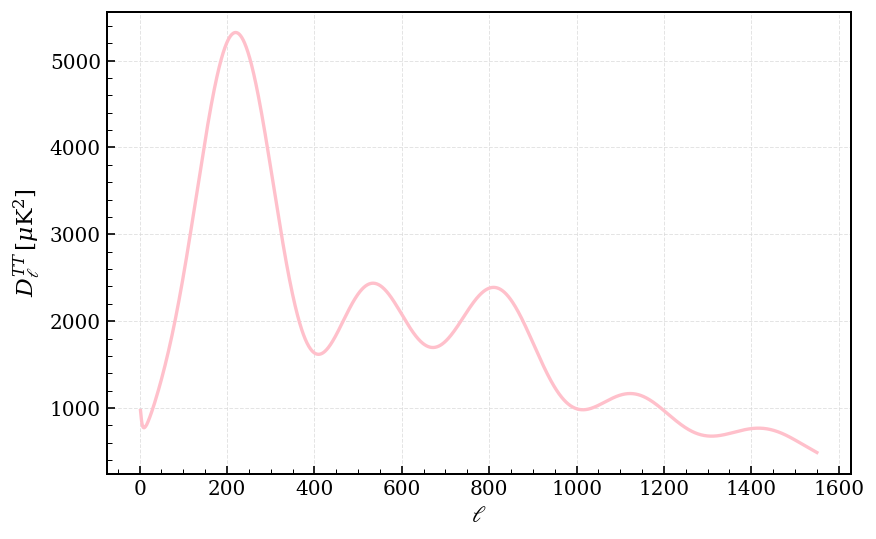

In [3]:
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, lmax=1500)

results = camb.get_results(pars)
powers = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True) 
cl_tt = powers["lensed_scalar"][:, 0]
ells = np.arange(len(cl_tt))
cl_tt[:2] = 0.0
Dl_tt = ells * (ells + 1) * cl_tt / (2 * np.pi)

plt.figure(figsize=(8,5))
plt.plot(ells[2:], cl_tt[2:], color='pink')
plt.yscale("log")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{TT}\,[\mu \mathrm{K}^2]$")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ells[2:], Dl_tt[2:], color='pink')
plt.xlabel(r"$\ell$")
plt.ylabel(r"$D_\ell^{TT}\,[\mu \mathrm{K}^2]$")
plt.show()

In [4]:
ells

array([   0,    1,    2, ..., 1548, 1549, 1550], shape=(1551,))

/tmp/ipykernel_1497/2495502755.py:5: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  alm_master = hp.synalm(cl_tt, lmax=lmax_master, new=True, verbose=False)
/tmp/ipykernel_1497/2495502755.py:10: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  map_1024 = hp.alm2map(alm, nside=NSIDE, lmax=lmax_map, pol=False, verbose=False)


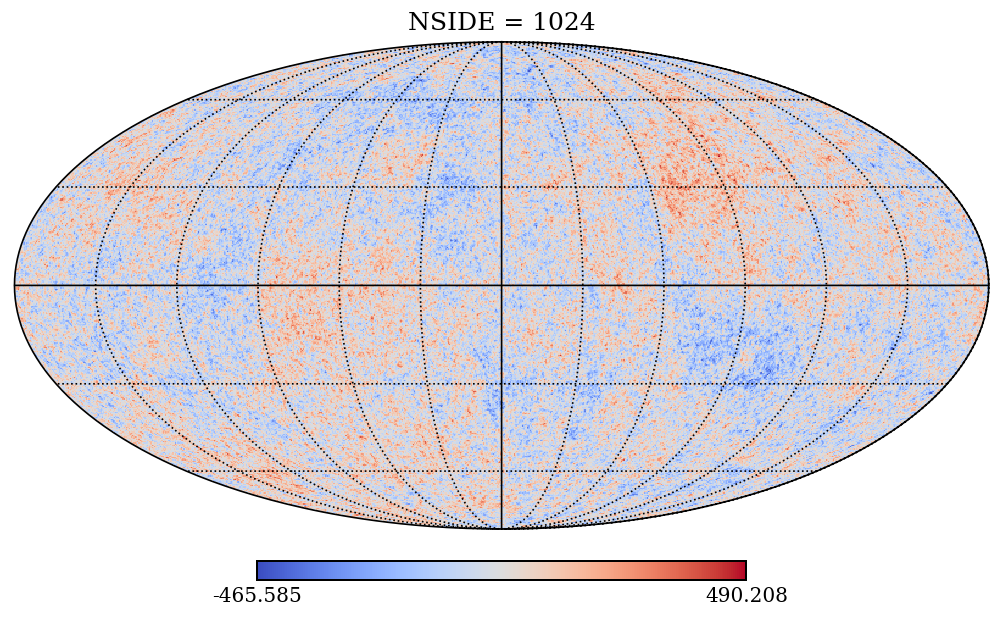

In [5]:
seed = 113403063
np.random.seed(seed)

lmax_master = len(cl_tt) - 1
alm_master = hp.synalm(cl_tt, lmax=lmax_master, new=True, verbose=False)
NSIDE = 1024
lmax1 = 3*NSIDE - 1
lmax_map = min(lmax_master, lmax1)
alm = hp.resize_alm(alm_master, lmax=lmax_master, mmax=lmax_master, lmax_out=lmax_map, mmax_out=lmax_map)
map_1024 = hp.alm2map(alm, nside=NSIDE, lmax=lmax_map, pol=False, verbose=False)


hp.mollview(map_1024, title=f"NSIDE = {NSIDE}", cmap="coolwarm")
hp.graticule()
plt.show()

In [6]:
print(f"Número de pixeles en este mapa (NSIDE = {NSIDE}):", len(map_1024))
pixeles=12*NSIDE*NSIDE
print(f"pixeles = {pixeles}")

Número de pixeles en este mapa (NSIDE = 1024): 12582912
pixeles = 12582912


In [7]:
temp_promedio = np.mean(map_1024)
temp_desv = np.std(map_1024)
print(f"Temperatura promedio: {temp_promedio:.12f} microK")

Temperatura promedio: 0.000001162685 microK


In [8]:
seed = 207790273
rng = np.random.default_rng(seed)
npix = 12*NSIDE*NSIDE
pix_elegido = rng.integers(0, npix)
theta_pix, phi_pix = hp.pix2ang(NSIDE, pix_elegido)
vec0 = hp.ang2vec(theta_pix, phi_pix)
temp0 = map_1024[pix_elegido]

print("Pixel elegido:", pix_elegido)
print("theta [rad]:", theta_pix)
print("phi [rad]:", phi_pix)
print("Temperatura en ese punto [microK]:", temp0)

Pixel elegido: 6946363
theta [rad]: 1.6751522993833503
phi [rad]: 2.4474663470715403
Temperatura en ese punto [microK]: 73.70855029908074


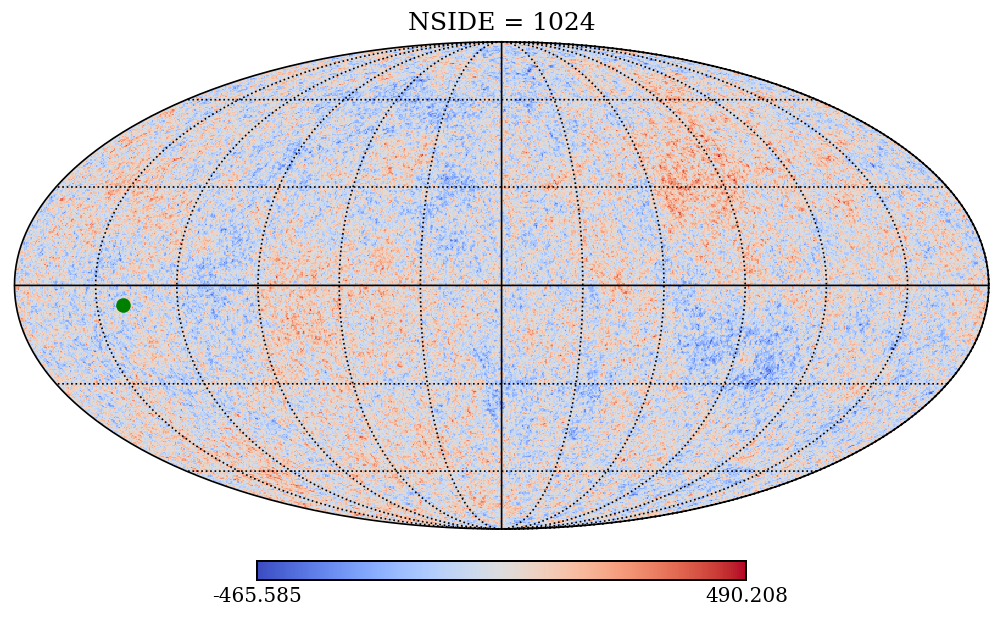

In [9]:
hp.mollview(map_1024, title=f"NSIDE = {NSIDE}", cmap="coolwarm")
hp.projscatter(theta_pix, phi_pix, marker="o", s=60, color='green')
hp.graticule()
plt.show()

In [ ]:
NSIDE=1024
seed = 113403063
rng = np.random.default_rng(seed)
n_puntos = 20860
npix = 12*NSIDE*NSIDE
r_inicial = 0.2
r_final = 30.2
ancho_anillo = 0.5
j=0
bordes_radiales = np.arange(r_inicial, r_final + ancho_anillo, ancho_anillo)

radios_internos = bordes_radiales[:-1] #eliminamos el último radio
radios_externos = bordes_radiales[1:] #eliminamos el primer radio
radios_medios = (radios_internos + radios_externos) / 2

temperaturas_todos_los_puntos = [] #Acá juntamos las temperaturas de todos los puntos contenidos en un anillo para cada punto. Será una lista de listas
pixeles_elegidos = [] #Acá se guardan los pixeles aleatorios con los que se trabajarán (su longitud corresponde al número de puntos aleatorios)
temps_puntos = [] #Acá se guardarán las temperaturas medias de cada anillo
temperatura_media_anillos = [] #la longitud  de esta lista debiese ser equivalente al número de puntos, cada elemento es una lista
for i in range(n_puntos):
    j+=1
    print(j)
    pix_elegido = rng.integers(0, npix) #para cada punto se elige un pixel aleatorio
    pixeles_elegidos.append(pix_elegido)
    theta_pix, phi_pix = hp.pix2ang(NSIDE, pix_elegido) #pixel a coordenadas angulares
    vec_i = hp.ang2vec(theta_pix, phi_pix) #dirección angular a un vector 3d
    temperatura_media_anillos_i = []
    for r_interno_anillo, r_externo_anillo in zip(radios_internos, radios_externos):
        pix_disco_externo = hp.query_disc(nside=NSIDE, vec=vec_i, radius=np.radians(r_externo_anillo), inclusive=True)
        pix_disco_interno = hp.query_disc(nside=NSIDE, vec=vec_i, radius=np.radians(r_interno_anillo), inclusive=True)
        pix_anillo = np.setdiff1d(pix_disco_externo, pix_disco_interno)
        temp_media = np.mean(map_1024[pix_anillo])
        temperatura_media_anillos_i.append(temp_media)
    temperatura_media_anillos.append(temperatura_media_anillos_i)


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [ ]:
len(temperatura_media_anillos)

3

In [ ]:
a = np.array(temperatura_media_anillos)
temperatura_promedios = np.mean(a, axis=0)

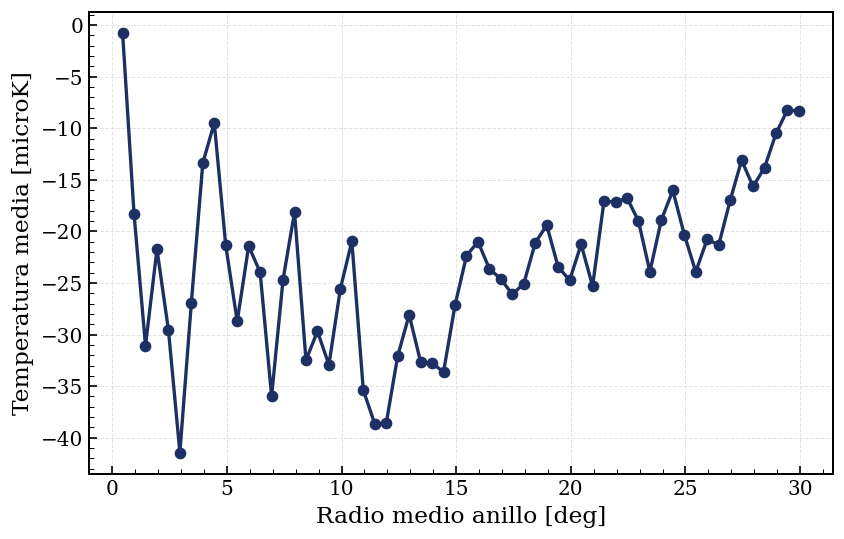

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(radios_medios, temperatura_promedios, marker="o", linestyle="-", color="#631D51")

plt.xlabel("Radio medio anillo [deg]")
plt.ylabel("Temperatura media [microK]")

plt.grid(True)
plt.show()

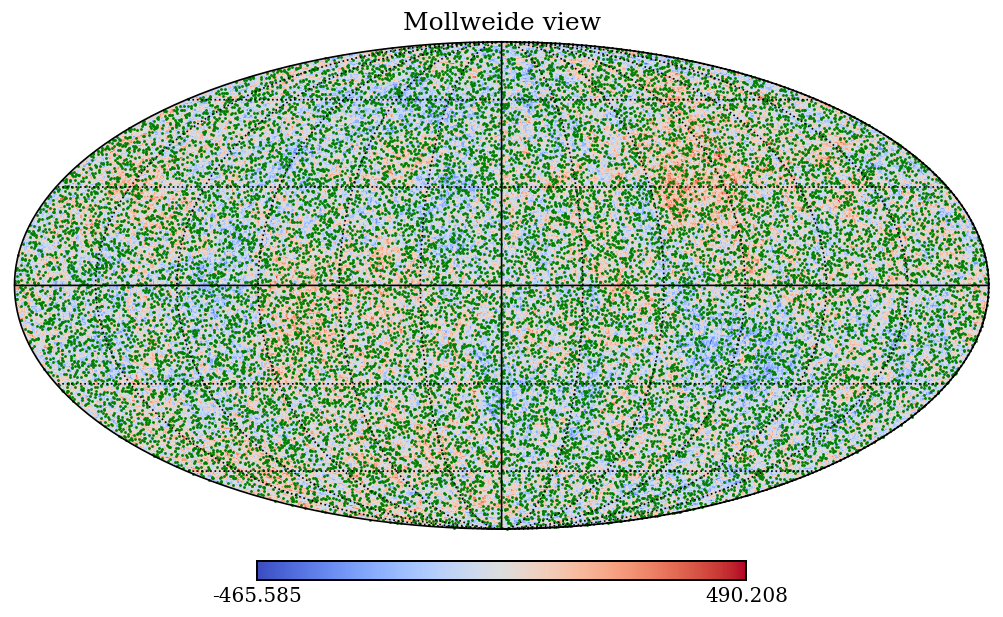

In [ ]:
theta_pix, phi_pix = hp.pix2ang(NSIDE, pixeles_elegidos)

hp.mollview(
    map_1024,
    cmap="coolwarm"
)

hp.projscatter(
    theta_pix,
    phi_pix,
    marker=".",
    s=2,
    color="green",
    alpha=1
)

hp.graticule()
plt.show()